# デモレース

In [1]:
# 変更部分を適用するリロードのおまじない
%load_ext autoreload
%autoreload 2

# ロガー準備
import logging
import sys

# 1. rootロガーを取得
logger = logging.getLogger()

# 2. ログレベルを設定 (DEBUG, INFO, WARNING など)
logger.setLevel(logging.INFO)

# 3. Jupyterの標準出力に書き出すハンドラを作成
# すでにハンドラが存在する場合は追加しない（二重出力を防ぐ）
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    
    # 読みやすいフォーマットを設定
    formatter = logging.Formatter('%(levelname)s: %(name)s: %(message)s')
    handler.setFormatter(formatter)
    
    logger.addHandler(handler)

# テスト: これで engine.py 内のログも表示されるようになります
logging.info("Jupyterのロガー設定が完了しました。")

INFO: root: Jupyterのロガー設定が完了しました。


In [12]:
# テスト用レースデータの作成

from src.simulator import RaceSimulator, RaceEvent
from src.services.factory.demo_factory import DemoRaceFactory

# 検証用
from src.services.research_helper import ResearchResultSaver

factory = DemoRaceFactory()
sim = RaceSimulator(factory)
sim.attach(ResearchResultSaver())

# テスト設定
distance = 1600
surface = "dirt"
num_horses = 8

race_info_list = sim.prepare(distance=distance, surface=surface, num_horses=num_horses)

# テスト馬設定
h1_id = "D000000001"
h2_id = "D000000002"
h3_id = "D000000003"
h4_id = "D000000004"
h5_id = "D000000005"
h6_id = "D000000006"
h7_id = "D000000007"
h8_id = "D000000008"

h1_spec = {"strategy": 0}
h2_spec = {"strategy": 1}
h3_spec = {"strategy": 2}
h4_spec = {"strategy": 3}
h5_spec = {"strategy": 0}
h6_spec = {"strategy": 1}
h7_spec = {"strategy": 2}
h8_spec = {"strategy": 3}

race_info1 = race_info_list[0]

horse1 = race_info1.profile.horses[h1_id]
horse2 = race_info1.profile.horses[h2_id]
horse3 = race_info1.profile.horses[h3_id]
horse4 = race_info1.profile.horses[h4_id]
horse5 = race_info1.profile.horses[h5_id]
horse6 = race_info1.profile.horses[h6_id]
horse7 = race_info1.profile.horses[h7_id]
horse8 = race_info1.profile.horses[h8_id]

horse1_update = factory.horse_factory.setup_horse_profile(horse1, **h1_spec)
horse2_update = factory.horse_factory.setup_horse_profile(horse2, **h2_spec)
horse3_update = factory.horse_factory.setup_horse_profile(horse3, **h3_spec)
horse4_update = factory.horse_factory.setup_horse_profile(horse4, **h4_spec)
horse5_update = factory.horse_factory.setup_horse_profile(horse5, **h5_spec)
horse6_update = factory.horse_factory.setup_horse_profile(horse6, **h6_spec)
horse7_update = factory.horse_factory.setup_horse_profile(horse7, **h7_spec)
horse8_update = factory.horse_factory.setup_horse_profile(horse8, **h8_spec)

demo_horses = {
    h1_id: horse1_update,
    h2_id: horse2_update,
    h3_id: horse3_update,
    h4_id: horse4_update,
    h5_id: horse5_update,
    h6_id: horse6_update,
    h7_id: horse7_update,
    h8_id: horse8_update,
}
demo_race_info = factory.update_horses_in_race_info(race_info1, demo_horses)
race_info_list[0] = demo_race_info

# 準備データ保存
sim.notify(RaceEvent.PREPARE, {'data': race_info_list})

INFO: src.simulator: 初期化中...
INFO: src.core.engine: 初期化中...
INFO: src.services.saver: 初期化中...
INFO: src.services.research_helper: 初期化中...
INFO: src.services.factory.demo_factory: 馬 dummy_horse_1 の能力値を設定しました >> {'strategy': 0}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_2 の能力値を設定しました >> {'strategy': 1}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_3 の能力値を設定しました >> {'strategy': 2}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_4 の能力値を設定しました >> {'strategy': 3}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_5 の能力値を設定しました >> {'strategy': 0}


INFO: src.services.factory.demo_factory: 馬 dummy_horse_6 の能力値を設定しました >> {'strategy': 1}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_7 の能力値を設定しました >> {'strategy': 2}
INFO: src.services.factory.demo_factory: 馬 dummy_horse_8 の能力値を設定しました >> {'strategy': 3}
INFO: src.services.saver: prepared/100001010001_DEMO_dirt1600に結果を保存しました。


In [13]:
# レース実行

for race_info in race_info_list:
    history = sim._run_single_race(race_info)
    sim.results[race_info.race_id] = history
    sim.notify(RaceEvent.FINISH, {'data': race_info, 'history': history})

INFO: src.services.saver: results/100001010001_DEMO_dirt1600に結果を保存しました。
INFO: src.services.research_helper: researchs/100001010001_DEMO_dirt1600に結果を保存しました。


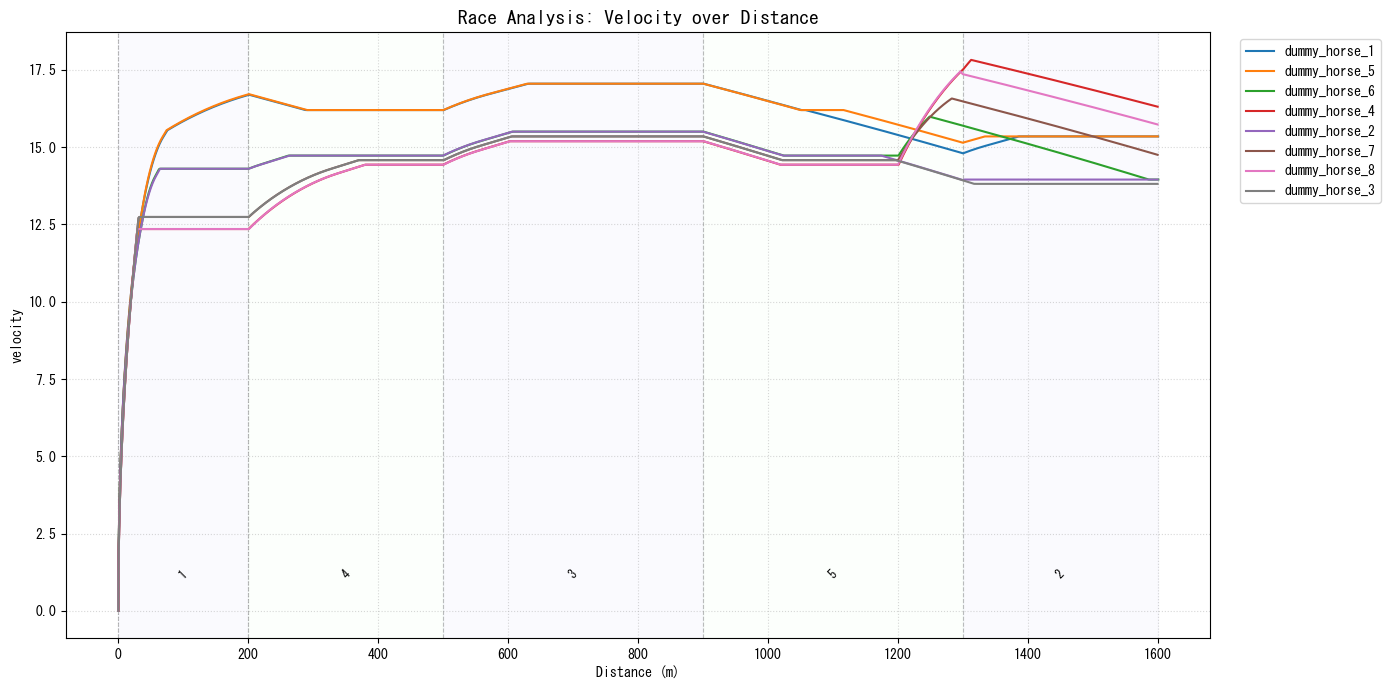

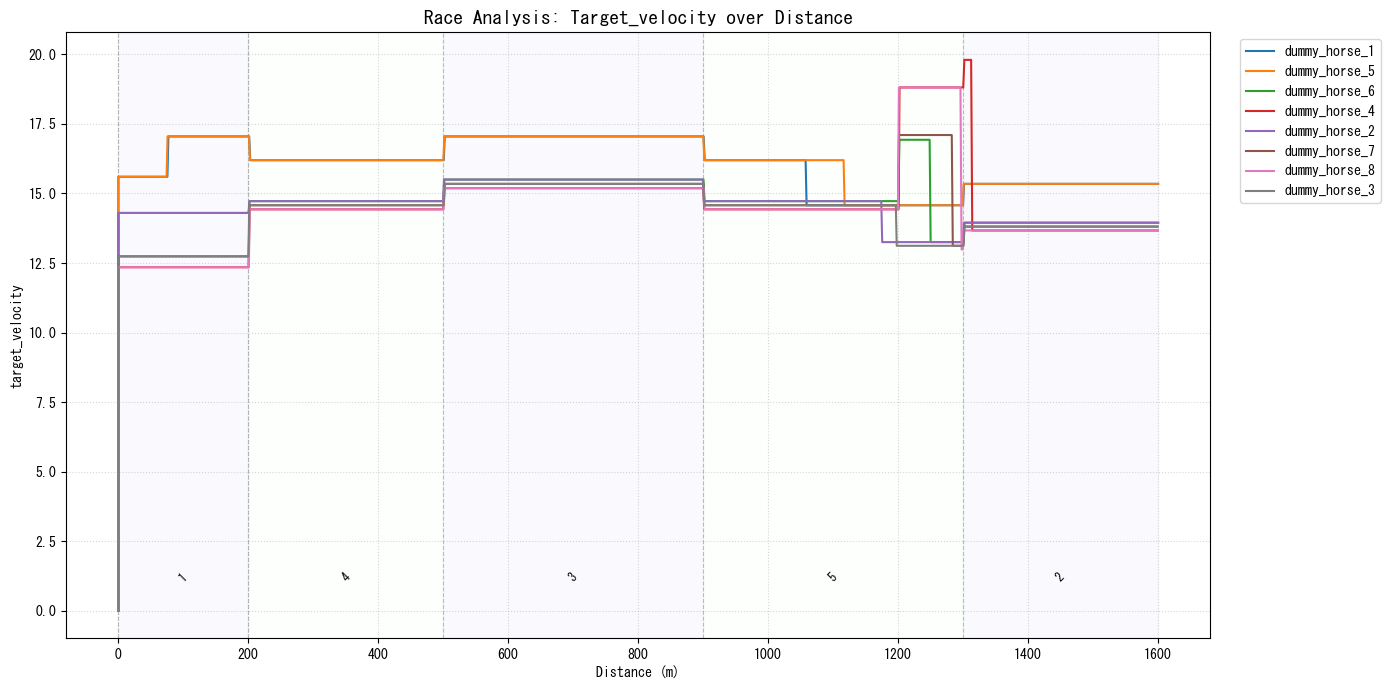

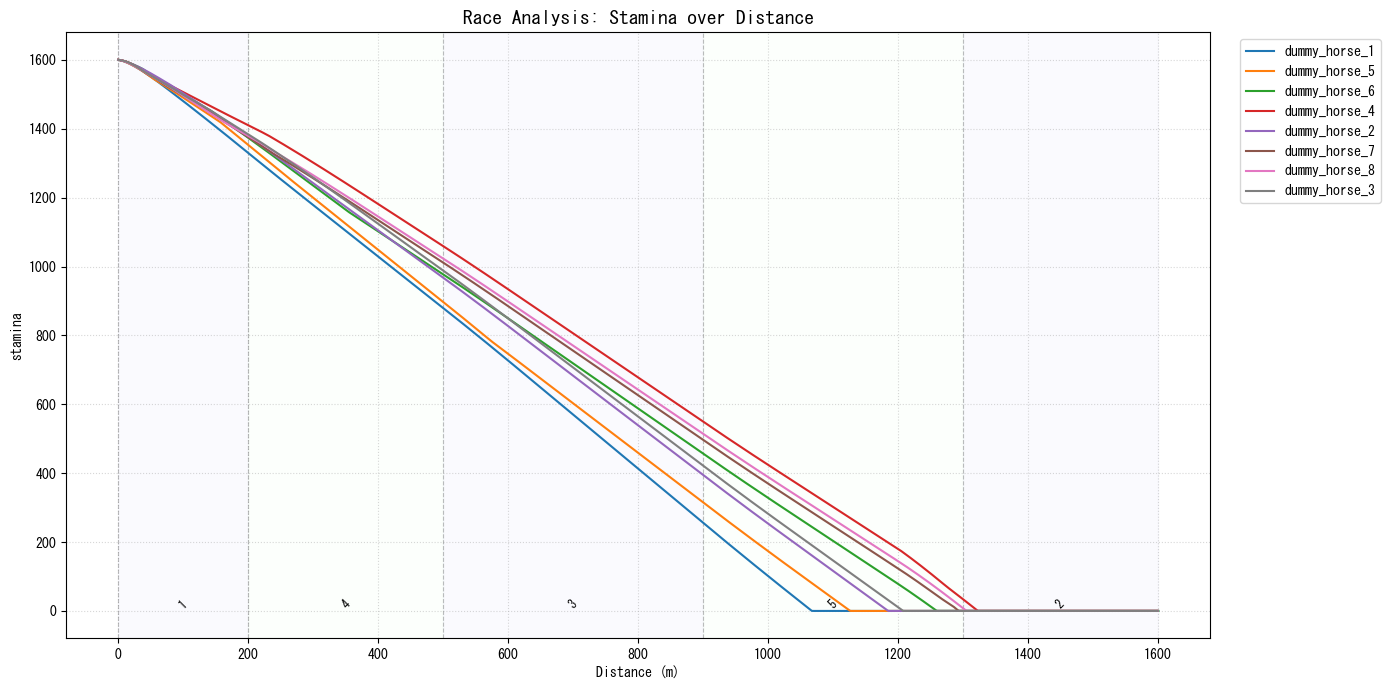

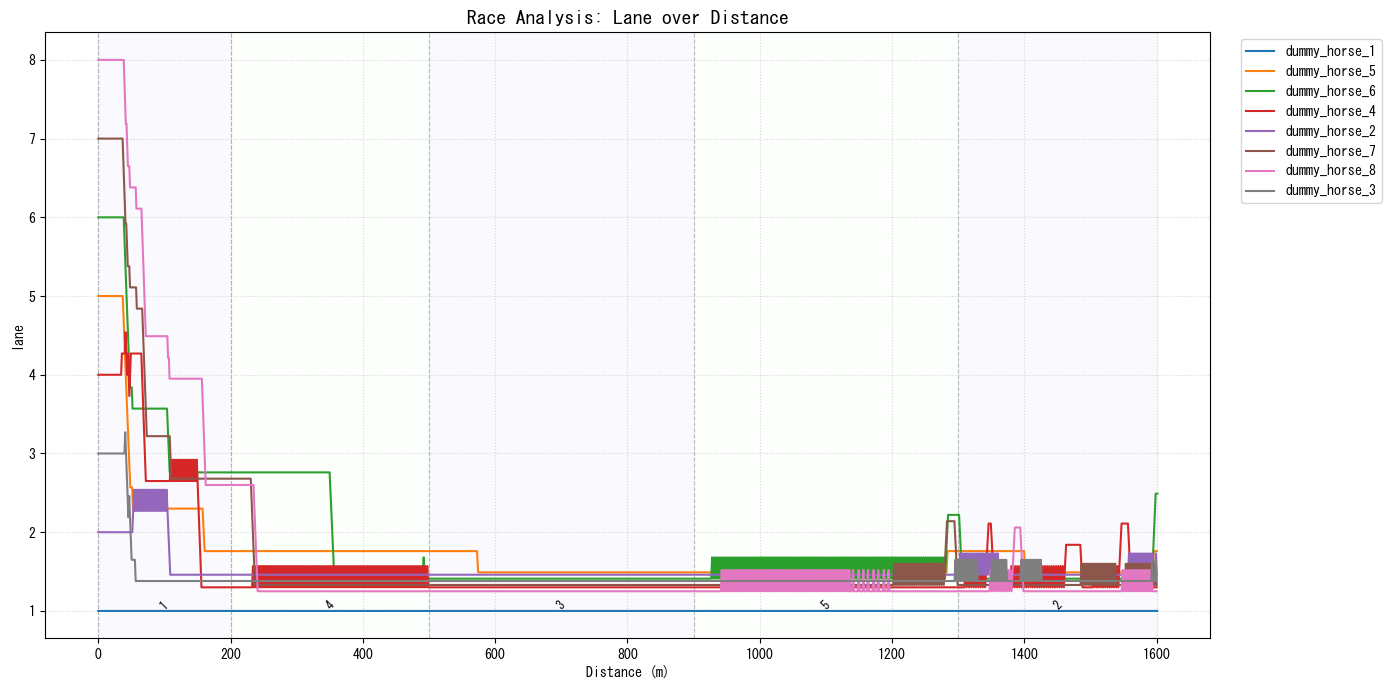

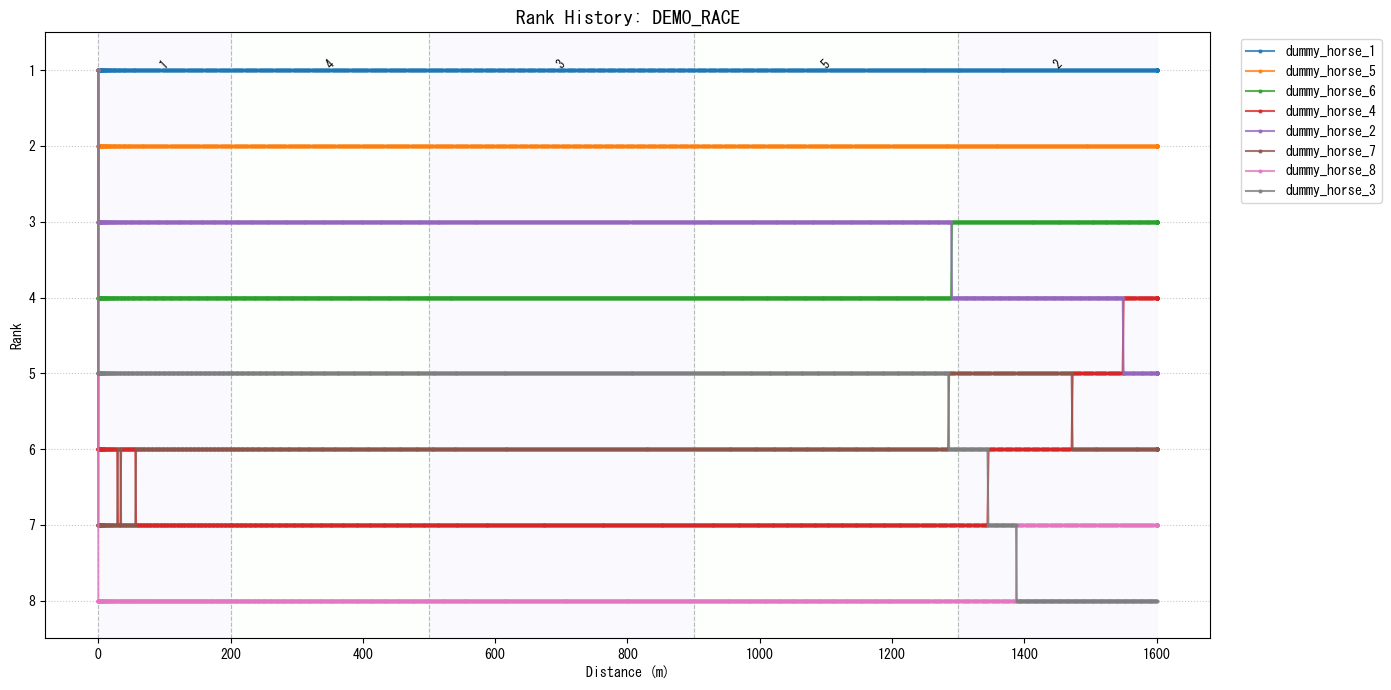

In [14]:
# プロット描画（全レース）
from src.services.research_helper import RaceResultPlotter

plt = RaceResultPlotter()

for race_info in race_info_list:
    history = sim.results[race_info.race_id]
    plt.plot_race_analysis(history, race_info.profile, "velocity")
    plt.plot_race_analysis(history, race_info.profile, "target_velocity")
    plt.plot_race_analysis(history, race_info.profile, "stamina")
    plt.plot_race_analysis(history, race_info.profile, "lane")
    plt.plot_race_rank_history(history, race_info.profile)